# Converting a temporal DatasetCollection to NetCDF

A `DatasetCollection` is a *time-series of aligned rasters* — conceptually a `(time, band, y, x)` cube backed
by a folder of GeoTIFFs. Writing it to a single **NetCDF** collapses that folder into one self-describing CF
file with a real `time` dimension, which is far easier to move around and open in xarray, QGIS, or Panoply than
a pile of dated `.tif` files.

| Input | Output |
|-------|--------|
| folder of dated GeoTIFFs | one NetCDF with a `time` dimension of length *T* |

The whole trip is `DatasetCollection.read_multiple_files(folder).to_netcdf(path)`. This notebook covers the
**multi-timestep** case. For single-file raster⇄NetCDF conversions (one GeoTIFF's bands
to variables and back), see [Converting between GeoTIFF and NetCDF](geotiff-netcdf.ipynb).

## Setup

In [1]:
%matplotlib inline

import tempfile
from pathlib import Path

import pandas as pd

DATA = Path('../../../examples/data')
WORK = Path(tempfile.mkdtemp(prefix='pyramids-collection-nc-'))  # scratch dir for outputs
DATA.is_dir(), WORK.is_dir()

(True, True)

In [2]:
from pyramids.dataset import DatasetCollection
from pyramids.netcdf import NetCDF
from pyramids.netcdf.plot_options import Selectors

## Build a temporal collection

`read_multiple_files` reads a folder of rasters into one stack. With `with_order=True` it parses the date in each
file name (here `MSWEP_1979.01.01.tif` → `file_name_data_fmt='%Y.%m.%d'`) and orders the timesteps by it, so the
collection gets a real **calendar** `time` axis rather than an arbitrary file order. The sample folder holds six
daily MSWEP rainfall rasters.

In [3]:
folder = DATA / 'geotiff' / 'raster-folder'
sorted(p.name for p in folder.glob('*.tif'))

['MSWEP_1979.01.01.tif',
 'MSWEP_1979.01.02.tif',
 'MSWEP_1979.01.03.tif',
 'MSWEP_1979.01.04.tif',
 'MSWEP_1979.01.05.tif',
 'MSWEP_1979.01.06.tif']

In [4]:
col = DatasetCollection.read_multiple_files(
    str(folder), with_order=True, file_name_data_fmt='%Y.%m.%d'
)
col.time_length, col.meta.band_names, col.meta.shape

(6, ('Band_1',), (1, 125, 93))

The parsed dates become the collection's `time` axis — this is what `to_netcdf` writes out as the NetCDF time
coordinate.

In [5]:
times = list(col.time)
times

[datetime.datetime(1979, 1, 1, 0, 0),
 datetime.datetime(1979, 1, 2, 0, 0),
 datetime.datetime(1979, 1, 3, 0, 0),
 datetime.datetime(1979, 1, 4, 0, 0),
 datetime.datetime(1979, 1, 5, 0, 0),
 datetime.datetime(1979, 1, 6, 0, 0)]

## Look at the stack

`iloc(i)` pulls timestep `i` out as a plain `Dataset`, so we can plot it. Compare the first and last days to see
the rainfall field change over the week.

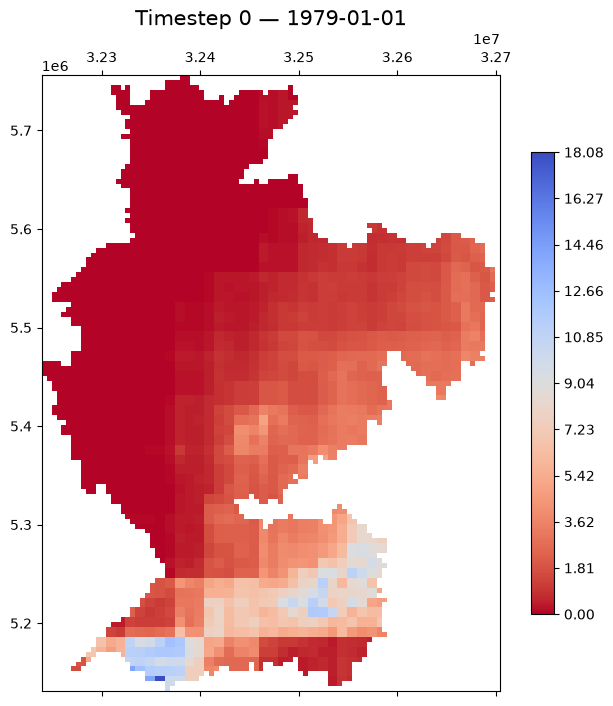

In [6]:
col.iloc(0).plot(band=0, title=f'Timestep 0 — {times[0]:%Y-%m-%d}')

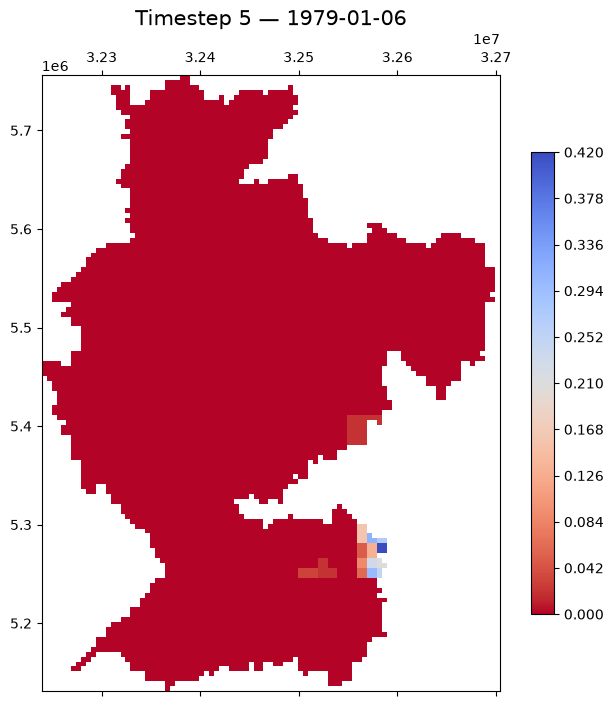

In [7]:
col.iloc(col.time_length - 1).plot(band=0, title=f'Timestep {col.time_length - 1} — {times[-1]:%Y-%m-%d}')

## Convert to a single NetCDF

One call. The calendar `time` axis is written automatically — you do **not** pass it. With the default
`var_per_band=True`, each band becomes its own CF variable and the band names carry through (this single-band
stack yields one variable, `Band_1`).

In [8]:
out = WORK / 'mswep_cube.nc'
col.to_netcdf(out)
out.stat().st_size  # bytes on disk

290330

## Read it back

`NetCDF.read_file` reopens the file through GDAL (no `netcdf4` / `h5netcdf` engine needed). The `time` dimension
and its length survive the round-trip, and each variable is shaped `(time, y, x)`.

In [9]:
nc = NetCDF.read_file(out)
nc.variable_names, nc.epsg

(['Band_1'], 4647)

In [10]:
nc.dimension_names, nc.dimension_sizes

(['time', 'x', 'y'], {'time': 6, 'x': 93, 'y': 125})

In [11]:
nc.get_variable('Band_1').shape  # (time, y, x)

(6, 125, 93)

Plot a timestep straight from the reopened NetCDF to confirm the pixels match the source. NetCDF plotting
selects along named dimensions, so pick the time slice with `Selectors(isel={'time': i})` rather than a flat band
index. The source's no-data fill is stored as a CF attribute, so pass `exclude_value` to mask it and the plot
lines up with the source above.

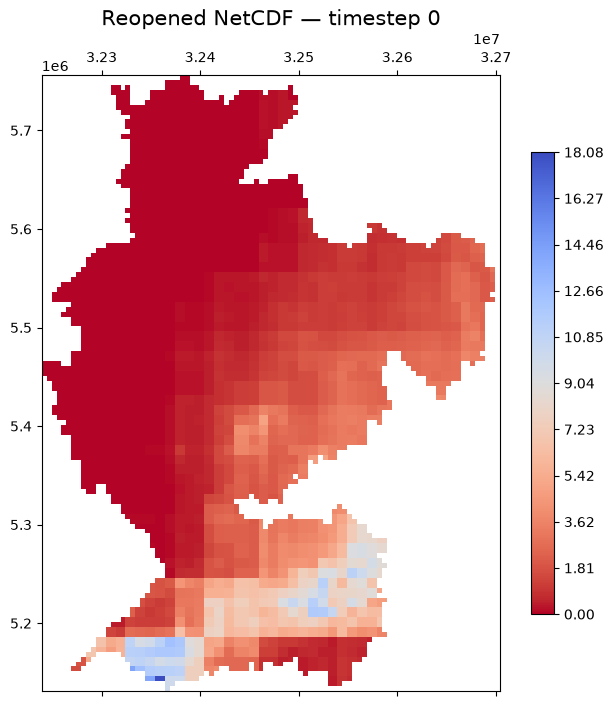

In [12]:
nodata = col.iloc(0).no_data_value[0]
nc.plot(
    variable='Band_1',
    selectors=Selectors(isel={'time': 0}),
    exclude_value=nodata,
    title='Reopened NetCDF — timestep 0',
)

## Give the cube your own time axis

When the file names carry no parseable date — or you simply want a different calendar — pass `time_coords`
explicitly. Its length must equal `time_length`.

In [13]:
dated = WORK / 'mswep_2020.nc'
col.to_netcdf(dated, time_coords=pd.date_range('2020-01-01', periods=col.time_length, freq='D'))
NetCDF.read_file(dated).dimension_sizes

{'time': 6, 'x': 93, 'y': 125}

## One 4-D variable instead of one-per-band

For cubes with many bands, `var_per_band=False` writes a single `data` variable carrying an extra `band`
dimension, instead of one variable per band.

In [14]:
cube4d = WORK / 'mswep_4d.nc'
col.to_netcdf(cube4d, var_per_band=False)
nc4 = NetCDF.read_file(cube4d)
nc4.variable_names, nc4.dimension_sizes

(['data'], {'band': 1, 'time': 6, 'x': 93, 'y': 125})

## Notes

- `to_netcdf` needs **xarray** installed — it assembles an `xarray.Dataset` in memory, then writes it through
  GDAL's multidimensional NetCDF driver (so no `netcdf4` / `h5netcdf` engine is required). Reading back with
  `NetCDF.read_file` is pure GDAL.
- It is **eager**: it materialises the full `(time, band, y, x)` cube in memory. Above ~2 GB it warns; for large
  cubes prefer `DatasetCollection.to_zarr`, which streams the data chunk-by-chunk.
- The output is CF-1.8 with the geobox attached (`crs_wkt` / `GeoTransform`); the time axis is CF-encoded as
  `nanoseconds since 1970-01-01`.
- See also: [Converting between GeoTIFF and NetCDF](geotiff-netcdf.ipynb) and the Zarr examples for very large
  cubes.